In [3]:
#imports
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [4]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [5]:
#Loading the models for Exercise 8.4
def load_model(model_path):

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    return model

In [6]:
pedestrian_model = load_model(
    "../models/pedestrian_model.pth"
)

vehicle_model = load_model(
    "../models/vehicle_model.pth"
)

traffic_light_model = load_model(
    "../models/traffic_light_model.pth"
)

In [7]:
models_dict = {
    "pedestrian": pedestrian_model,
    "vehicle": vehicle_model,
    "traffic_light": traffic_light_model
}

Excercise 8.4.1
Implementing FSGM for each binary classifier model


In [8]:
criterion = nn.BCEWithLogitsLoss()
def fgsm_attack(
    model,
    image,
    label,
    epsilon
):

    image = image.clone().detach()

    image.requires_grad = True

    output = model(image)

    loss = criterion(
        output,
        label
    )

    model.zero_grad()

    loss.backward()

    gradient = image.grad.data

    perturbation = (
        epsilon
        *
        gradient.sign()
    )

    adversarial_image = (
        image
        +
        perturbation
    )

    adversarial_image = torch.clamp(
        adversarial_image,
        0,
        1
    )

    return adversarial_image

In [9]:
test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)

print(test_df.columns.tolist())

print()

print(
    test_df[
        [
            "has_pedestrian",
            "has_vehicle",
            "has_traffic_light"
        ]
    ].sum()
)

['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

has_pedestrian        706
has_vehicle          2700
has_traffic_light    2584
dtype: int64


In [10]:
os.makedirs(
    "../results/excercise_8",
    exist_ok=True
)

In [11]:
models_dict = {

    "Pedestrian": (
        pedestrian_model,
        "has_pedestrian"
    ),

    "Vehicle": (
        vehicle_model,
        "has_vehicle"
    ),

    "Traffic Light": (
        traffic_light_model,
        "has_traffic_light"
    )
}

In [13]:
#Using the carladataset
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.target = target

        self.transform = transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()

        ])

    def __len__(self):

        return len(self.df)

    def __getitem__(self,idx):

        row = self.df.iloc[idx]

        frame = row["frame"]

        filename = f"{frame:06d}.jpg"

        path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(path).convert("RGB")

        image = self.transform(
            image
        )

        label = float(
            row[self.target]
        )

        return image,label

In [19]:
# Find a positive example that the model classifies correctly

def get_correct_positive_sample(
    dataframe,
    image_dir,
    target,
    model
):

    dataset = CarlaDataset(
        dataframe,
        image_dir,
        target
    )

    model.eval()

    for idx in range(len(dataset)):

        image,label = dataset[idx]

        if label != 1:
            continue

        with torch.no_grad():

            prob = torch.sigmoid(
                model(
                    image.unsqueeze(0).to(device)
                )
            ).item()

        if prob > 0.5:

            return image,label,prob

    return None,None,None

In [20]:
# Check that a correctly classified positive sample exists

for name,(model,target) in models_dict.items():

    image,label,prob = get_correct_positive_sample(

        test_df,

        "../datasets/test/rgb-front",

        target,

        model
    )

    print(
        f"{name}: "
        f"label={label}, "
        f"prob={prob:.3f}"
    )

Pedestrian: label=1.0, prob=0.587
Vehicle: label=1.0, prob=1.000
Traffic Light: label=1.0, prob=1.000


In [21]:
#So to get the model's predicted probability of an image, convert it using sigmoid

# Convert model output into probability

def predict_probability(
    model,
    image
):

    with torch.no_grad():

        output = model(image)

        probability = torch.sigmoid(
            output
        )

    return probability.item()

In [28]:
#Finidng a positive image sample and generate adversarial images using ε = 0.01, 0.05, 0.10


def create_fgsm_examples():

    epsilons = [
        0.01,
        0.05,
        0.10
    ]

    rows = []

    fig,axes = plt.subplots(
        3,
        4,
        figsize=(16,12)
    )

    model_names = [
        "Pedestrian Classifier",
        "Vehicle Classifier",
        "Traffic Light Classifier"
    ]

    for row,(name,(model,target)) in enumerate(
        models_dict.items()
    ):

        image,label,clean_prob = get_correct_positive_sample(

            test_df,

            "../datasets/test/rgb-front",

            target,

            model
        )

        image = image.unsqueeze(0).to(device)

        label = torch.tensor(
            [[label]],
            dtype=torch.float32
        ).to(device)

        clean_img = (
            image.squeeze()
            .cpu()
            .permute(1,2,0)
            .numpy()
        )

        # First image in row
        axes[row,0].imshow(
            clean_img
        )

        axes[row,0].axis("off")

        axes[row,0].set_title(
            f"{model_names[row]}\n\nClean\np={clean_prob:.3f}",
            fontsize=12,
            fontweight="bold"
        )

        rows.append(
            [
                name,
                "Clean",
                clean_prob
            ]
        )

        for col,epsilon in enumerate(
            epsilons,
            start=1
        ):

            adv = fgsm_attack(

                model,

                image,

                label,

                epsilon
            )

            adv_prob = predict_probability(
                model,
                adv
            )

            rows.append(
                [
                    name,
                    epsilon,
                    adv_prob
                ]
            )

            adv_img = (
                adv.squeeze()
                .detach()
                .cpu()
                .permute(1,2,0)
                .numpy()
            )

            axes[row,col].imshow(
                adv_img
            )

            axes[row,col].axis("off")

            axes[row,col].set_title(
                f"ε={epsilon}\np={adv_prob:.3f}",
                fontsize=11
            )

    plt.suptitle(
        "FGSM Adversarial Examples for CARLA Perception Models",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0,0,1,0.96]
    )

    plt.savefig(
        "../results/excercise_8/exercise8_fgsm_examples.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    results_df = pd.DataFrame(
        rows,
        columns=[
            "Model",
            "Epsilon",
            "Probability"
        ]
    )

    results_df.to_csv(

        "../results/excercise_8/exercise8_fgsm_results.csv",

        index=False
    )

    return results_df

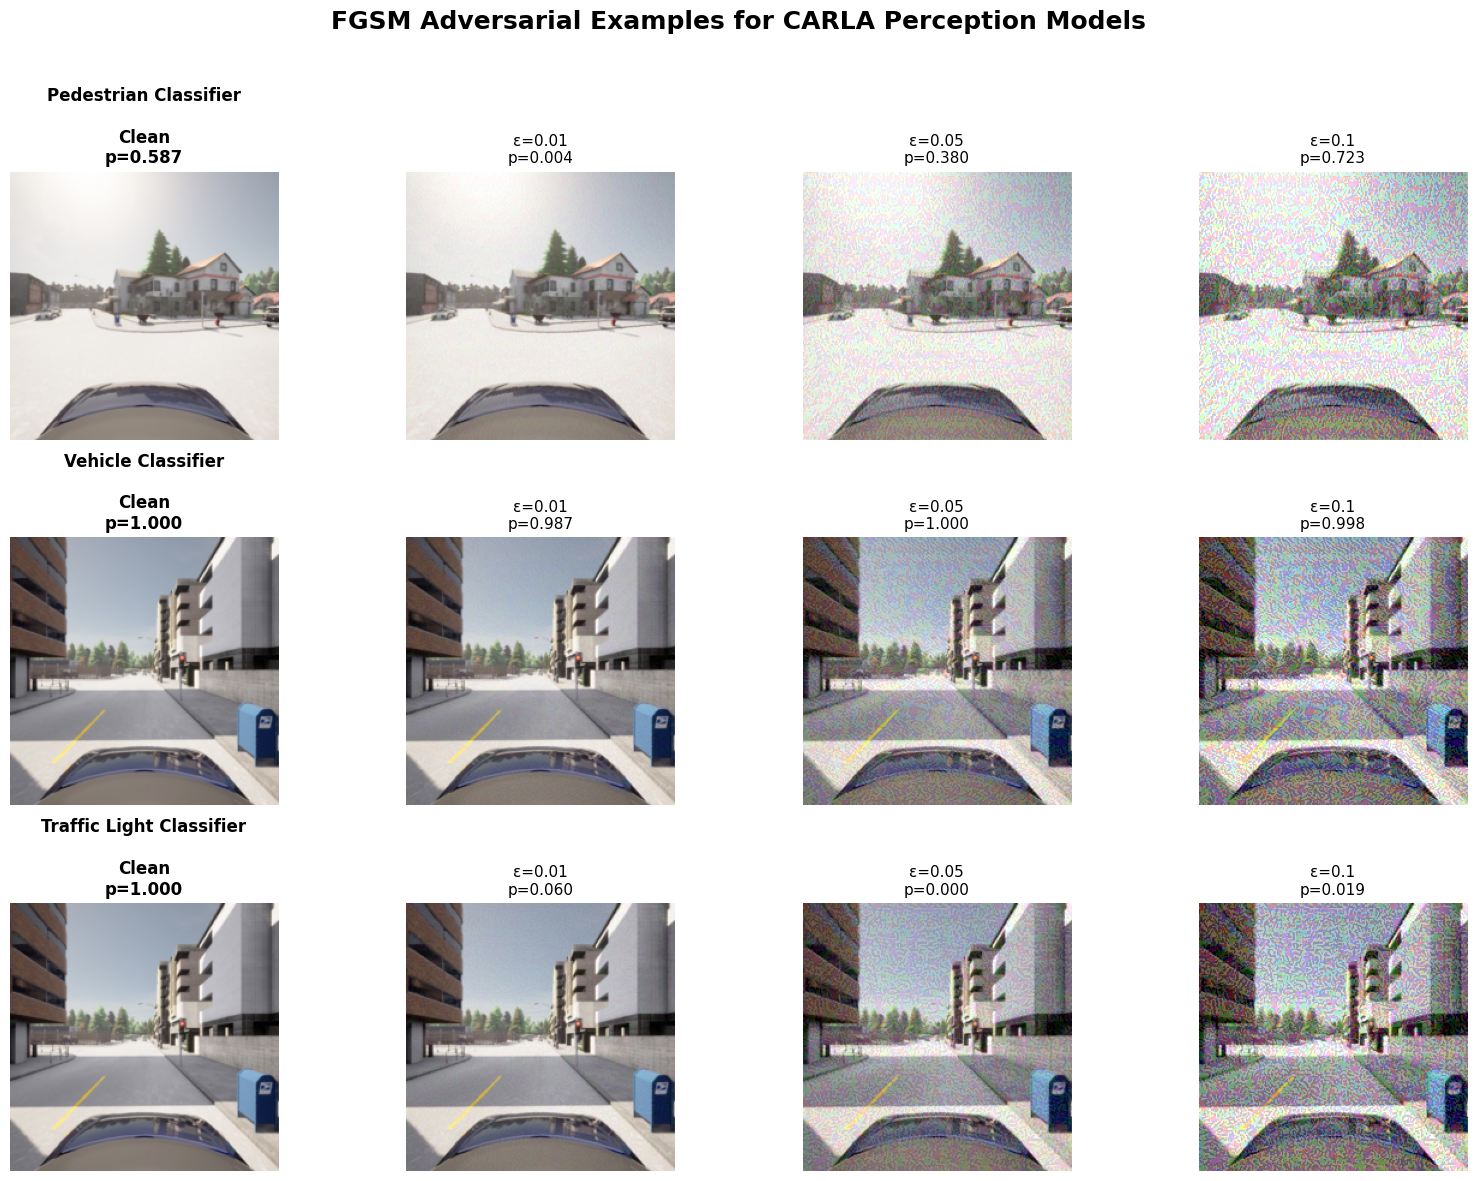

,Model,Epsilon,Probability
0,Pedestrian,Clean,0.586719
1,Pedestrian,0.01,0.004268
2,Pedestrian,0.05,0.379599
3,Pedestrian,0.1,0.722943
4,Vehicle,Clean,0.999974
5,Vehicle,0.01,0.986984
6,Vehicle,0.05,0.999725
7,Vehicle,0.1,0.998413
8,Traffic Light,Clean,0.999988
9,Traffic Light,0.01,0.060208


In [29]:
# Create adversarial examples

fgsm_results = create_fgsm_examples()

fgsm_results

In [30]:
#Excercise 8.5
#Robustness evaluation metrics
# Metrics for robustness evaluation

from sklearn.metrics import recall_score

In [31]:
#Creating a random subset. 100 samples according to the exercise sheet


subset_df = test_df.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

print(
    "Subset size:",
    len(subset_df)
)

Subset size: 100


In [32]:
#Evaluate recall on clean and advesarial images

def evaluate_recall_under_fgsm(
    model,
    target,
    dataframe,
    epsilon
):

    dataset = CarlaDataset(
        dataframe,
        "../datasets/test/rgb-front",
        target
    )

    clean_predictions = []
    adv_predictions = []
    labels = []

    model.eval()

    for idx in range(len(dataset)):

        image,label = dataset[idx]

        image = image.unsqueeze(0).to(device)

        label_tensor = torch.tensor(
            [[label]],
            dtype=torch.float32
        ).to(device)

        # Clean prediction
        with torch.no_grad():

            clean_prob = torch.sigmoid(
                model(image)
            ).item()

        clean_pred = int(
            clean_prob > 0.5
        )

        # Adversarial prediction
        adv_image = fgsm_attack(

            model,

            image,

            label_tensor,

            epsilon
        )

        with torch.no_grad():

            adv_prob = torch.sigmoid(
                model(adv_image)
            ).item()

        adv_pred = int(
            adv_prob > 0.5
        )

        labels.append(
            int(label)
        )

        clean_predictions.append(
            clean_pred
        )

        adv_predictions.append(
            adv_pred
        )

    clean_recall = recall_score(
        labels,
        clean_predictions
    )

    adv_recall = recall_score(
        labels,
        adv_predictions
    )

    return clean_recall,adv_recall

In [33]:
#Measuring recall drop for all the models

epsilons = [
    0.01,
    0.05,
    0.10
]

rows = []

for model_name,(model,target) in models_dict.items():

    for epsilon in epsilons:

        clean_recall,adv_recall = evaluate_recall_under_fgsm(

            model,

            target,

            subset_df,

            epsilon
        )

        recall_drop = (
            clean_recall
            -
            adv_recall
        )

        rows.append({

            "Model": model_name,

            "Epsilon": epsilon,

            "Clean Recall": clean_recall,

            "Adversarial Recall": adv_recall,

            "Recall Drop": recall_drop
        })

results_df = pd.DataFrame(
    rows
)

results_df

,Model,Epsilon,Clean Recall,Adversarial Recall,Recall Drop
0,Pedestrian,0.01,0.611111,0.055556,0.555556
1,Pedestrian,0.05,0.611111,0.777778,-0.166667
2,Pedestrian,0.10,0.611111,0.888889,-0.277778
3,Vehicle,0.01,0.987654,0.876543,0.111111
4,Vehicle,0.05,0.987654,1.000000,-0.012346
5,Vehicle,0.10,0.987654,1.000000,-0.012346
6,Traffic Light,0.01,0.985915,0.098592,0.887324
7,Traffic Light,0.05,0.985915,0.098592,0.887324
8,Traffic Light,0.10,0.985915,0.098592,0.887324


In [34]:
# Save robustness results

results_df.to_csv(

    "../results/excercise_8/exercise8_recall_drop.csv",

    index=False
)

results_df

,Model,Epsilon,Clean Recall,Adversarial Recall,Recall Drop
0,Pedestrian,0.01,0.611111,0.055556,0.555556
1,Pedestrian,0.05,0.611111,0.777778,-0.166667
2,Pedestrian,0.10,0.611111,0.888889,-0.277778
3,Vehicle,0.01,0.987654,0.876543,0.111111
4,Vehicle,0.05,0.987654,1.000000,-0.012346
5,Vehicle,0.10,0.987654,1.000000,-0.012346
6,Traffic Light,0.01,0.985915,0.098592,0.887324
7,Traffic Light,0.05,0.985915,0.098592,0.887324
8,Traffic Light,0.10,0.985915,0.098592,0.887324


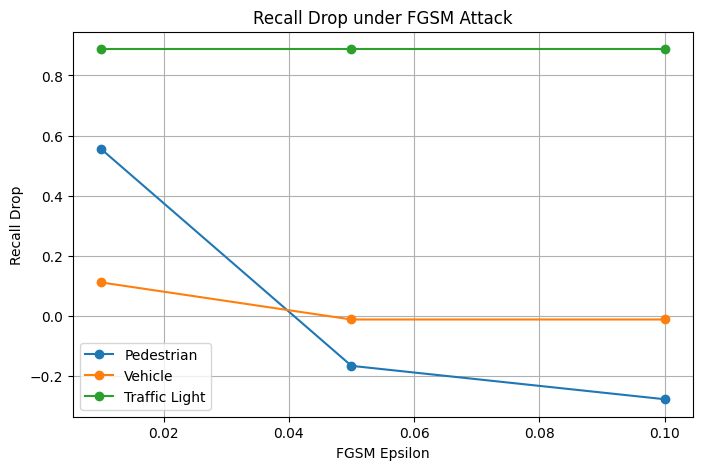

In [35]:
#Creating summary plot to understand the evaluation


plt.figure(
    figsize=(8,5)
)

for model_name in results_df["Model"].unique():

    temp = results_df[
        results_df["Model"] == model_name
    ]

    plt.plot(

        temp["Epsilon"],

        temp["Recall Drop"],

        marker="o",

        label=model_name
    )

plt.xlabel(
    "FGSM Epsilon"
)

plt.ylabel(
    "Recall Drop"
)

plt.title(
    "Recall Drop under FGSM Attack"
)

plt.legend()

plt.grid()

plt.savefig(

    "../results/excercise_8/exercise8_recall_drop.png",

    bbox_inches="tight"
)

plt.show()